Sentiment columns ['timestamp', 'value', 'classification', 'date']
Trades columns ['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side', 'timestamp ist', 'start position', 'direction', 'closed pnl', 'transaction hash', 'order id', 'crossed', 'fee', 'trade id', 'timestamp']
Proceeding by creating a placeholder 'leverage' column with a default value of 1.0.
timestamp ist closed pnl account size tokens placeholder_leverage side
Final dataset (530, 10)
                                      account       date      closedpnl  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-06-12 -175611.000056   
1  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-11       0.000000   
2  0x083384f897ee0f19899168e3b1bec365f52a9012 2025-01-03    9482.221441   
3  0x083384f897ee0f19899168e3b1bec365f52a9012 2025-02-02   76710.000000   
4  0x083384f897ee0f19899168e3b1bec365f52a9012 2025-03-02  101011.685664   

   num_trades   avg_size  leverage  long_ratio   timestamp  value  \
0       

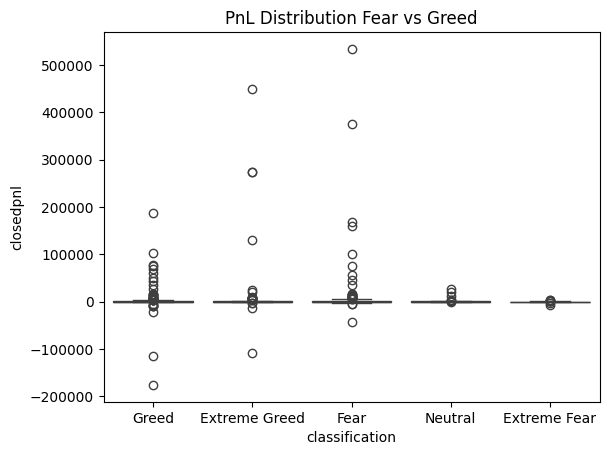

classification
Extreme Fear     0.424242
Extreme Greed    0.571429
Fear             0.630573
Greed            0.628272
Neutral          0.567568
Name: win, dtype: float64


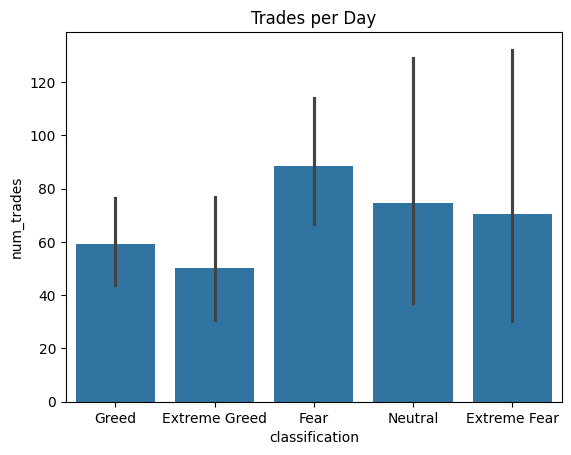

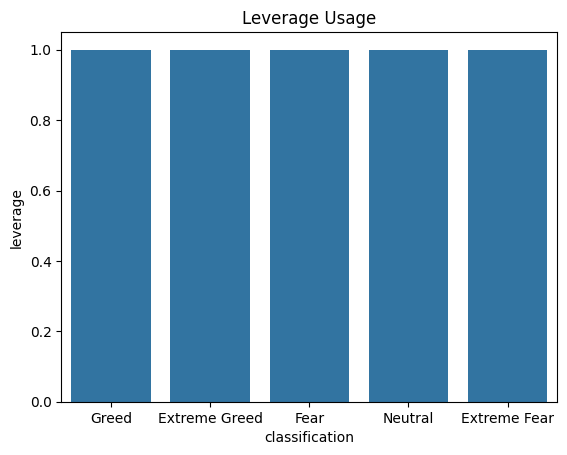

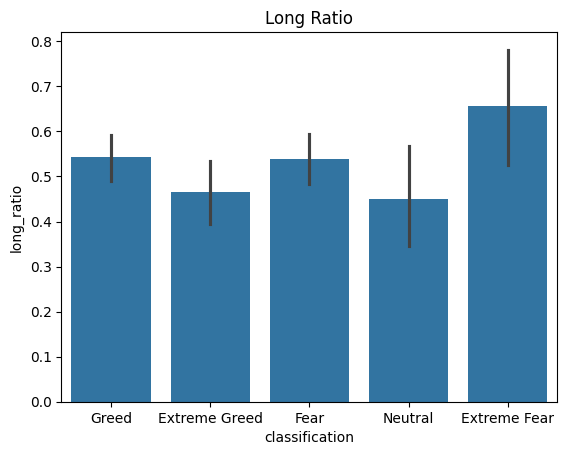

Model Accuracy 0.7169811320754716


In [3]:
# STEP 0 IMPORT DOWNLOAD LOAD
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown

gdown.download("https://drive.google.com/uc?id=1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf", "sentiment.csv", quiet=True)
gdown.download("https://drive.google.com/uc?id=1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs", "trades.csv", quiet=True)

sentiment = pd.read_csv("sentiment.csv")
trades = pd.read_csv("trades.csv")


# STEP 1 CLEAN COLUMN NAMES
sentiment.columns = sentiment.columns.str.strip().str.lower()
trades.columns = trades.columns.str.strip().str.lower()

print("Sentiment columns", sentiment.columns.tolist())
print("Trades columns", trades.columns.tolist())


# STEP 2 AUTO DETECT IMPORTANT COLUMNS
time_col = [col for col in trades.columns if "time" in col][0]
pnl_col = [col for col in trades.columns if "pnl" in col][0]
account_col = [col for col in trades.columns if col in ["account","user","wallet"]][0]
size_col = [col for col in trades.columns if "size" in col or "qty" in col or "amount" in col][0]

# Fix: Handle the case where 'leverage' column is not found
leverage_column_candidates = [col for col in trades.columns if "leverage" in col]
if not leverage_column_candidates:
    leverage_column_candidates = [col for col in trades.columns if "lev" in col]

if leverage_column_candidates:
    lev_col = leverage_column_candidates[0]
else:
    print("Warning: No 'leverage' column (or column containing 'lev' or 'leverage') found in trades data.")
    print("Proceeding by creating a placeholder 'leverage' column with a default value of 1.0.")
    # Create a placeholder column if actual leverage data is missing
    lev_col = "placeholder_leverage" # A temporary name to be used for creation
    trades[lev_col] = 1.0 # Default value, assuming no leverage

side_col = [col for col in trades.columns if "side" in col][0]

print(time_col, pnl_col, account_col, size_col, lev_col, side_col)


# STEP 3 RENAME TO STANDARD NAMES
trades.rename(columns={
    time_col: "time",
    pnl_col: "closedpnl",
    account_col: "account",
    size_col: "size",
    lev_col: "leverage",
    side_col: "side"
}, inplace=True)


# STEP 4 DATE PROCESSING
trades["time"] = pd.to_datetime(trades["time"], errors="coerce")
sentiment["date"] = pd.to_datetime(sentiment["date"], errors="coerce")

trades = trades.dropna(subset=["time"])
sentiment = sentiment.dropna(subset=["date"])

trades["date"] = trades["time"].dt.floor("D")
sentiment["date"] = sentiment["date"].dt.floor("D")


# STEP 5 CLEAN DATA
trades = trades.drop_duplicates()
sentiment = sentiment.drop_duplicates()

for col in ["closedpnl", "size", "leverage"]:
    trades[col] = pd.to_numeric(trades[col], errors="coerce")

trades = trades.dropna(subset=["closedpnl", "size", "leverage", "side"])


# STEP 6 FEATURE ENGINEERING
daily_pnl = trades.groupby(["account", "date"])["closedpnl"].sum().reset_index()
trade_count = trades.groupby(["account", "date"]).size().reset_index(name="num_trades")
avg_size = trades.groupby(["account", "date"])["size"].mean().reset_index(name="avg_size")
leverage = trades.groupby(["account", "date"])["leverage"].mean().reset_index()

trades["long"] = trades["side"].astype(str).str.upper().str.contains("BUY").astype(int)
long_ratio = trades.groupby(["account", "date"])["long"].mean().reset_index(name="long_ratio")


# STEP 7 MERGE DATA
df = daily_pnl.merge(trade_count, on=["account", "date"])
df = df.merge(avg_size, on=["account", "date"])
df = df.merge(leverage, on=["account", "date"])
df = df.merge(long_ratio, on=["account", "date"])

df = df.merge(sentiment, on="date")

print("Final dataset", df.shape)
print(df.head())


# STEP 8 ANALYSIS
sns.boxplot(x="classification", y="closedpnl", data=df)
plt.title("PnL Distribution Fear vs Greed")
plt.show()

df["win"] = (df["closedpnl"] > 0).astype(int)
print(df.groupby("classification")["win"].mean())

sns.barplot(x="classification", y="num_trades", data=df)
plt.title("Trades per Day")
plt.show()

sns.barplot(x="classification", y="leverage", data=df)
plt.title("Leverage Usage")
plt.show()

sns.barplot(x="classification", y="long_ratio", data=df)
plt.title("Long Ratio")
plt.show()


# STEP 9 SEGMENTATION
df["leverage_segment"] = np.where(df["leverage"] > df["leverage"].median(), "High", "Low")
df["trader_type"] = np.where(df["num_trades"] > df["num_trades"].median(), "Frequent", "Infrequent")

vol = df.groupby("account")["closedpnl"].std().reset_index()
vol.columns = ["account", "volatility"]

df = df.merge(vol, on="account")

df["consistency"] = np.where(df["volatility"] < df["volatility"].median(), "Consistent", "Inconsistent")


# STEP 10 BONUS MODEL
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

df["profit"] = (df["closedpnl"] > 0).astype(int)

X = df[["num_trades", "leverage", "avg_size", "long_ratio"]]
y = df["profit"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Model Accuracy", model.score(X_test, y_test))